# World Cup 2026 Bracket Predictor



## 1. Imports

In [ ]:
import csv
import random
import pickle

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 60)
plt.rcParams["figure.facecolor"] = "white"


## 2. Load data

`teams.csv` — pre-tournament Elo seed per team (48-team field, roughly calibrated to
pre-tournament rankings/market strength).

`matches.csv` — every match played so far: group stage through the Round of 16,
with scores, a knockout flag, and a penalty-shootout winner column for matches
decided on penalties.

In [2]:
teams_df = pd.read_csv("data/teams.csv")
matches_df = pd.read_csv("data/matches.csv")

print(f"{len(teams_df)} teams seeded, {len(matches_df)} matches played so far")
teams_df.sort_values("pre_tournament_elo", ascending=False).head(10)


50 teams seeded, 96 matches played so far


,team,pre_tournament_elo
0,Spain,2080
1,Argentina,2065
2,France,2055
3,England,2040
4,Brazil,2035
5,Portugal,2000
6,Netherlands,1980
7,Belgium,1965
8,Germany,1960
9,Italy,1955


In [3]:
matches_df.head()


,home_team,away_team,home_goals,away_goals,is_knockout,penalties_winner
0,Mexico,South Africa,2,0,False,NaN
1,South Korea,Czechia,2,1,False,NaN
2,Czechia,South Africa,1,1,False,NaN
3,Mexico,South Korea,1,0,False,NaN
4,Czechia,Mexico,0,3,False,NaN


## 3. Elo rating engine

Standard Elo expected-score formula, with a goal-difference multiplier (bigger wins
move the rating more) and an extra K-factor boost for knockout matches (higher
stakes, more signal). Draws resolved by penalties give the shootout winner a small
0.6/0.4 credit split rather than a full point, since a shootout is closer to a coin
flip than a "real" win.

In [ ]:
K_BASE = 28            
K_KNOCKOUT_BOOST = 6    


def expected_score(r_a, r_b):
    return 1.0 / (1.0 + 10 ** ((r_b - r_a) / 400))


def goal_diff_multiplier(gd):
    if gd <= 1:
        return 1.0
    elif gd == 2:
        return 1.5
    return (11 + gd) / 8


def update_elo(ratings, home, away, home_goals, away_goals, knockout=False, penalties_winner=None):
    r_home, r_away = ratings[home], ratings[away]
    exp_home = expected_score(r_home, r_away)
    exp_away = 1 - exp_home

    if home_goals > away_goals:
        actual_home, actual_away, gd = 1.0, 0.0, home_goals - away_goals
    elif away_goals > home_goals:
        actual_home, actual_away, gd = 0.0, 1.0, away_goals - home_goals
    else:
        if penalties_winner == home:
            actual_home, actual_away = 0.6, 0.4
        elif penalties_winner == away:
            actual_home, actual_away = 0.4, 0.6
        else:
            actual_home, actual_away = 0.5, 0.5
        gd = 0

    k = K_BASE + (K_KNOCKOUT_BOOST if knockout else 0)
    mult = goal_diff_multiplier(gd)

    ratings[home] = r_home + k * mult * (actual_home - exp_home)
    ratings[away] = r_away + k * mult * (actual_away - exp_away)


## 4. Replay every match to build current-form Elo

Start from the pre-tournament seeds, then walk through `matches.csv` in order,
updating ratings after every result.

In [5]:
ratings = dict(zip(teams_df["team"], teams_df["pre_tournament_elo"].astype(float)))

for _, m in matches_df.iterrows():
    update_elo(
        ratings,
        m["home_team"], m["away_team"],
        int(m["home_goals"]), int(m["away_goals"]),
        knockout=bool(m["is_knockout"]),
        penalties_winner=m["penalties_winner"] if pd.notna(m["penalties_winner"]) else None,
    )

elo_df = (
    pd.DataFrame(ratings.items(), columns=["team", "current_elo"])
    .merge(teams_df, on="team")
    .assign(change=lambda d: d["current_elo"] - d["pre_tournament_elo"])
    .sort_values("current_elo", ascending=False)
    .reset_index(drop=True)
)
elo_df.head(15)


,team,current_elo,pre_tournament_elo,change
0,Spain,2110.102399,2080,30.102399
1,Argentina,2095.963343,2065,30.963343
2,England,2081.337906,2040,41.337906
3,France,2070.895513,2055,15.895513
4,Brazil,2014.812664,2035,-20.187336
5,Belgium,2012.488391,1965,47.488391
6,Portugal,1983.056422,2000,-16.943578
7,Netherlands,1975.776966,1980,-4.223034
8,Morocco,1965.228331,1920,45.228331
9,Norway,1963.215785,1870,93.215785


### Elo movement for the remaining quarterfinalists

In [6]:
remaining = ["Argentina", "Switzerland", "France", "Morocco",
             "Spain", "Belgium", "Norway", "England"]

remaining_df = elo_df[elo_df["team"].isin(remaining)].sort_values("current_elo", ascending=False)
remaining_df


,team,current_elo,pre_tournament_elo,change
0,Spain,2110.102399,2080,30.102399
1,Argentina,2095.963343,2065,30.963343
2,England,2081.337906,2040,41.337906
3,France,2070.895513,2055,15.895513
5,Belgium,2012.488391,1965,47.488391
8,Morocco,1965.228331,1920,45.228331
9,Norway,1963.215785,1870,93.215785
13,Switzerland,1948.199267,1905,43.199267


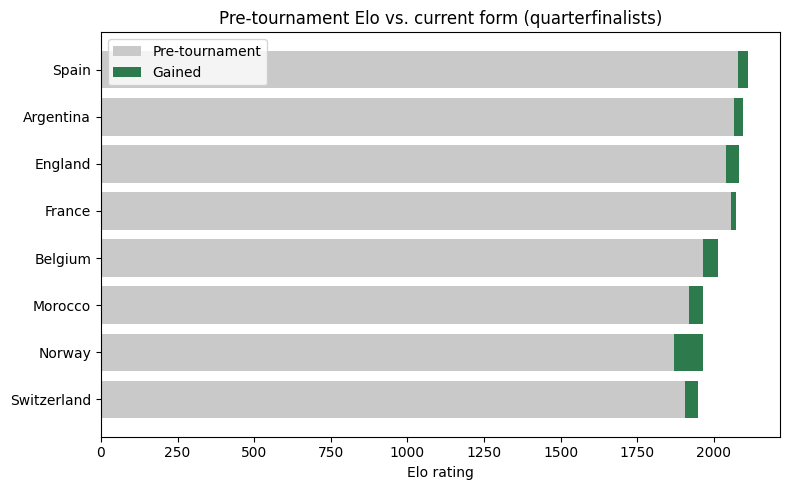

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
order = remaining_df.sort_values("current_elo")
ax.barh(order["team"], order["pre_tournament_elo"], color="#c9c9c9", label="Pre-tournament")
ax.barh(order["team"], order["change"].clip(lower=0), left=order["pre_tournament_elo"],
        color="#2d7a4d", label="Gained")
ax.set_xlabel("Elo rating")
ax.set_title("Pre-tournament Elo vs. current form (quarterfinalists)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Bracket structure and Monte Carlo simulation

Confirmed quarterfinal matchups, with the bracket path locked in: the France/Morocco
and Spain/Belgium winners meet in one semifinal, Argentina/Switzerland and
Norway/England winners meet in the other.

Each simulated match uses the Elo expected-score formula directly as a win
probability — this **is** a logistic regression on Elo difference, since that's
exactly what the Elo formula computes.

In [ ]:
QUARTERFINALS = [
    ("France", "Morocco"),
    ("Spain", "Belgium"),
    ("Argentina", "Switzerland"),
    ("Norway", "England"),
]
SF_PAIRING = [(0, 1), (2, 3)]  # QF1 winner vs QF2 winner, QF3 winner vs QF4 winner

N_SIMS = 100_000


def simulate_match(team_a, team_b, ratings, rng):
    p_a = expected_score(ratings[team_a], ratings[team_b])
    return team_a if rng.random() < p_a else team_b


def simulate_tournament(ratings, rng):
    qf_winners = [simulate_match(a, b, ratings, rng) for a, b in QUARTERFINALS]
    sf_winners = [simulate_match(qf_winners[i], qf_winners[j], ratings, rng) for i, j in SF_PAIRING]
    champion = simulate_match(sf_winners[0], sf_winners[1], ratings, rng)
    return qf_winners, sf_winners, champion


### Quarterfinal win probabilities

In [9]:
for a, b in QUARTERFINALS:
    p = expected_score(ratings[a], ratings[b])
    print(f"{a:<12} {p*100:5.1f}%   vs   {(1-p)*100:5.1f}% {b}")


France        64.8%   vs    35.2% Morocco
Spain         63.7%   vs    36.3% Belgium
Argentina     70.1%   vs    29.9% Switzerland
Norway        33.6%   vs    66.4% England


### Run the simulation

In [10]:
rng = random.Random(42)
teams = sorted({t for pair in QUARTERFINALS for t in pair})
reach_sf = {t: 0 for t in teams}
reach_final = {t: 0 for t in teams}
win_title = {t: 0 for t in teams}

for _ in range(N_SIMS):
    qf_w, sf_w, champ = simulate_tournament(ratings, rng)
    for t in qf_w:
        reach_sf[t] += 1
    for t in sf_w:
        reach_final[t] += 1
    win_title[champ] += 1

results_df = pd.DataFrame([
    {
        "team": t,
        "elo": round(ratings[t], 1),
        "reach_semis_%": round(100 * reach_sf[t] / N_SIMS, 1),
        "reach_final_%": round(100 * reach_final[t] / N_SIMS, 1),
        "win_title_%": round(100 * win_title[t] / N_SIMS, 1),
    }
    for t in teams
]).sort_values("win_title_%", ascending=False).reset_index(drop=True)

results_df


,team,elo,reach_semis_%,reach_final_%,win_title_%
0,Spain,2110.1,63.5,38.4,22.1
1,Argentina,2096.0,70.3,40.4,22.0
2,England,2081.3,66.4,35.8,18.7
3,France,2070.9,65.0,32.0,16.5
4,Belgium,2012.5,36.5,17.2,7.5
5,Morocco,1965.2,35.0,12.3,4.7
6,Norway,1963.2,33.6,12.8,4.6
7,Switzerland,1948.2,29.7,11.1,3.9


### Title odds, visualized

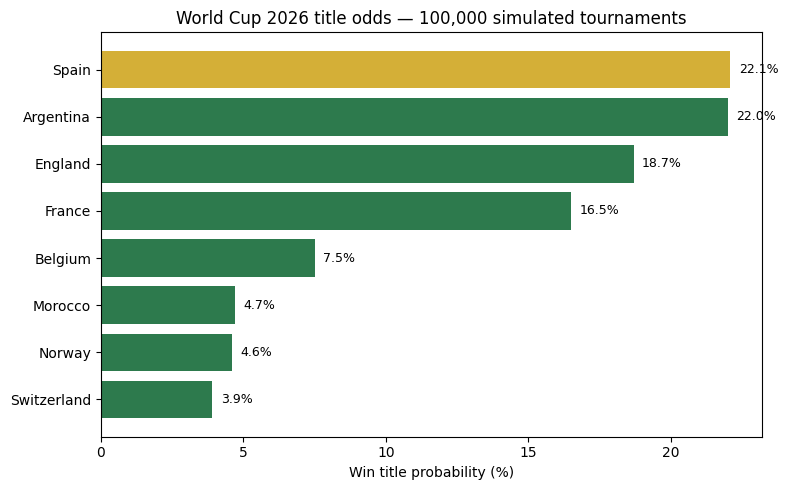

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
order = results_df.sort_values("win_title_%")
colors = ["#d4af37" if t == results_df.iloc[0]["team"] else "#2d7a4d" for t in order["team"]]
ax.barh(order["team"], order["win_title_%"], color=colors)
ax.set_xlabel("Win title probability (%)")
ax.set_title(f"World Cup 2026 title odds — {N_SIMS:,} simulated tournaments")
for i, (team, pct) in enumerate(zip(order["team"], order["win_title_%"])):
    ax.text(pct + 0.3, i, f"{pct}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Save trained artifacts

Same output format as `model.py`, so these `.pkl` files are drop-in compatible
with `app.py` if you want to regenerate them from this notebook instead.

In [12]:
with open("models/elo_ratings.pkl", "wb") as f:
    pickle.dump(ratings, f)

with open("models/simulation_results.pkl", "wb") as f:
    pickle.dump({
        "quarterfinals": QUARTERFINALS,
        "sf_pairing": SF_PAIRING,
        "results": results_df.rename(columns={
            "reach_semis_%": "reach_semis_pct",
            "reach_final_%": "reach_final_pct",
            "win_title_%": "win_title_pct",
        }).to_dict("records"),
        "n_sims": N_SIMS,
    }, f)

print("Saved models/elo_ratings.pkl and models/simulation_results.pkl")


Saved models/elo_ratings.pkl and models/simulation_results.pkl


## 7. Next steps

- Re-run cell 4 after each round completes — just append the new results to
  `data/matches.csv` first (same six columns: `home_team, away_team, home_goals,
  away_goals, is_knockout, penalties_winner`).
- Update `QUARTERFINALS` / add `SEMIFINALS` and `FINAL` brackets as the tournament progresses.
- Try swapping the raw Elo win-probability formula for a proper `sklearn`
  `LogisticRegression` trained on `(elo_diff, is_knockout, ...)` → match outcome,
  using the historical results in `matches.csv` as training data.